In [1]:
import hoda
import tensorly as tl
import mne
import os
%load_ext autoreload
%autoreload 2


%env TENSORLY_BACKEND=numpy
%env CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


tl.set_backend(os.environ['TENSORLY_BACKEND'])
tl.get_backend()

env: TENSORLY_BACKEND=numpy
env: CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


'numpy'

In [2]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = BNCI2014_004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[4],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
740 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  120 events (all good), 3 – 7.5 s, baseline off, ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  140 events (all good), 3 – 7.5 s, baseline off, ~3.6 MB, data loaded,
 'left_hand': 70
 'right_hand': 70>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  160 events (all good), 3 – 7.5 s, baseline off, ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epo

In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=False)
X = tl.tensor(X)
y = labels
X.shape

/tmp/ipykernel_1794458/884623113.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()
/vsc-hard-mounts/leuven-user/352/vsc35289/hoda-bci/src/hoda/tensorize.py:49: FutureWarning: The default value of `zero_mean` will change from `False` to `True` in version 1.8. Set the value explicitly to avoid this warning.
  Xt = np.abs(tfr_array_morlet(X, sfreq, **morlet_params))


(120, 3, 16, 72)

In [4]:
import numpy as np
np.any(X==0)

False

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning

env: PYTHONWARNINGS=ignore::FutureWarning


In [6]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True, n_splits=10),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1, 1)	score: 0.9780
Trying rank (2, 2, 2)	score: 0.9500
Trying rank (3, 4, 4)	score: 0.9100
Trying rank (3, 8, 8)	score: 0.8750
Trying rank (3, 16, 16)	score: 0.8490
Trying rank (3, 16, 32)	score: 0.7220
Trying rank (3, 16, 64)	score: 0.6440

Selected rank (1, 1, 1) with score 0.9780
New ranks: [(1, 1, 1)]


Model selection block 2/4...

Trying rank (1, 1, 1)	score: 0.9470
Trying rank (2, 2, 2)	score: 0.9670
Trying rank (3, 4, 4)	score: 0.9630
Trying rank (3, 8, 8)	score: 0.9620
Trying rank (3, 16, 16)	score: 0.9410
Trying rank (3, 16, 32)	score: 0.9070
Trying rank (3, 16, 64)	score: 0.8950

Selected rank (2, 2, 2) with score 0.9670
New ranks: [(1, 1, 1), (2, 2, 2)]


Model selection block 3/4...

Trying rank (1, 1, 1)	score: 0.9240
Trying rank (2, 2, 2)	score: 0.9420
Trying rank (3, 4, 4)	score: 0.9290
Trying rank (3, 8, 8)	score: 0.9290
Trying rank (3, 16, 16)	score: 0.9030
Trying rank (3, 16, 32)	score: 0.9090
Trying rank (3, 16, 64)	sco

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.05)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x146b3dda8220>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (1, 1, 1),
                         'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                         'toeplitz': None, 'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [7]:
bttda.model_select_info_.groupby(['block', 'rank']).val_score.aggregate('mean')

block  rank       
0      (1, 1, 1)      0.978
       (2, 2, 2)      0.950
       (3, 4, 4)      0.910
       (3, 8, 8)      0.875
       (3, 16, 16)    0.849
       (3, 16, 32)    0.722
       (3, 16, 64)    0.644
1      (1, 1, 1)      0.947
       (2, 2, 2)      0.967
       (3, 4, 4)      0.963
       (3, 8, 8)      0.962
       (3, 16, 16)    0.941
       (3, 16, 32)    0.907
       (3, 16, 64)    0.895
2      (1, 1, 1)      0.924
       (2, 2, 2)      0.942
       (3, 4, 4)      0.929
       (3, 8, 8)      0.929
       (3, 16, 16)    0.903
       (3, 16, 32)    0.909
       (3, 16, 64)    0.897
3      (1, 1, 1)      0.934
       (2, 2, 2)      0.934
       (3, 4, 4)      0.920
       (3, 8, 8)      0.917
       (3, 16, 16)    0.893
       (3, 16, 32)    0.909
       (3, 16, 64)    0.875
Name: val_score, dtype: float64

In [8]:
Xt = bttda.transform(X)

In [9]:
import seaborn as sns
import numpy as np

corr = np.abs(np.corrcoef(tl.to_numpy(Xt), rowvar=False))
sns.heatmap(corr, vmin=0)

ValueError: Must pass 2-d input. shape=()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

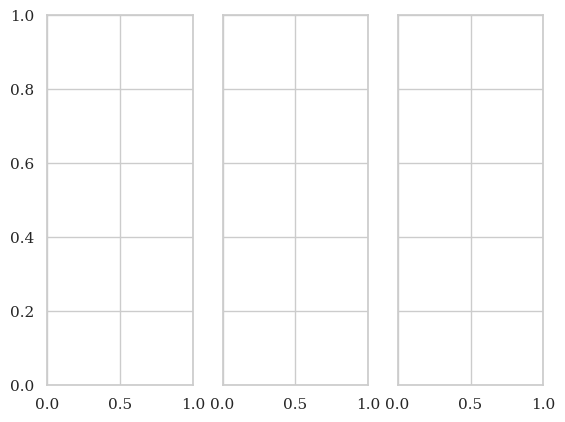

In [10]:
fig, axs = plt.subplots(bttda.n_blocks_,3, sharey=True)
for b,block in enumerate(bttda.blocks_):
    for k in range(3):
        axs[b,k].plot(block.weights_[k])



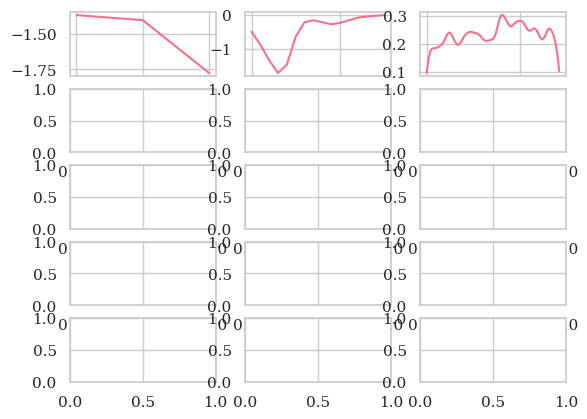

In [14]:
fig, axs = plt.subplots(5,3, sharey=False)
for b,block in enumerate(bttda.blocks_[:5]):
    for k in range(3):
        axs[b,k].plot(block.aps_[k])

block  rank  n_features
0      2     1             0.956944
1      2     1             0.956944
2      2     1             0.956944
3      3     1             0.956944
Name: val_score, dtype: float64

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:111

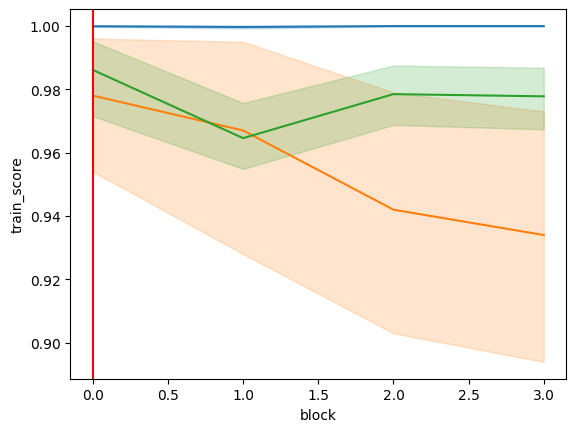

In [15]:
import seaborn as sns 
import matplotlib.pyplot as plt
df_select = bttda.model_select_info_best_
plt.style.use('default')
sns.lineplot(data=df_select, x='block',y='train_score')
sns.lineplot(data=df_select, x='block',y='val_score')
sns.lineplot(data=df_select, x='block',y='test_score')

plt.axvline(bttda.n_blocks_-1, color='red')

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.lineplot(data=bttda.train_info_, x='block',y='nmse')


ValueError: Could not interpret value `nmse` for parameter `y`